In [18]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

import numpy as np
import matplotlib.pyplot as plt

from qiskit.visualization import plot_distribution
from qiskit.visualization import plot_histogram

from qiskit_aer.primitives import SamplerV2 as Sampler

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


In [19]:
def execute_on_simulater(circuit):
    sim = AerSimulator()

    compiled_circuit = transpile(circuit, sim)

    job = sim.run(compiled_circuit, shots=1024) 
    result = job.result()

    counts = result.get_counts(compiled_circuit)
    print(counts)

    fig = plot_histogram(result.get_counts(compiled_circuit))

    display(fig)
    
    return result

In [20]:
def get_statevector_array(circuit):
    circuit = circuit.copy()
    circuit.save_statevector()
    circuit = transpile(circuit, backend=simulator)
    job = simulator.run(circuit)
    result = job.result()
    qiskit_statevector = result.data()['statevector']

    return np.asarray(qiskit_statevector)

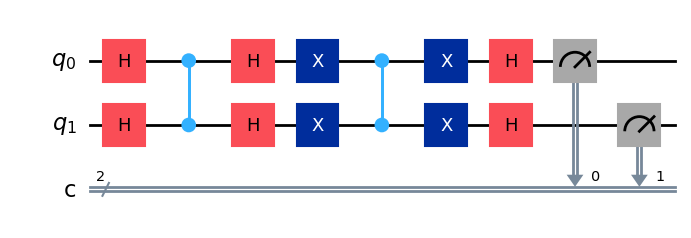

In [21]:
qreg_q = QuantumRegister(2, 'q')

creg_c = ClassicalRegister(2, 'c')

circuit = QuantumCircuit(qreg_q, creg_c)

circuit.h(qreg_q[0])
circuit.h(qreg_q[1])

#Oracle
circuit.cz(qreg_q[0], qreg_q[1])

#Diffuser
circuit.h(qreg_q[0])
circuit.h(qreg_q[1])

circuit.x(qreg_q[0])
circuit.x(qreg_q[1])

#
circuit.cz(qreg_q[0], qreg_q[1])

circuit.x(qreg_q[0])
circuit.x(qreg_q[1])

circuit.h(qreg_q[0])
circuit.h(qreg_q[1])

#
circuit.measure(qreg_q[0], creg_c[0])
circuit.measure(qreg_q[1], creg_c[1])

circuit.draw('mpl')

{'11': 1024}


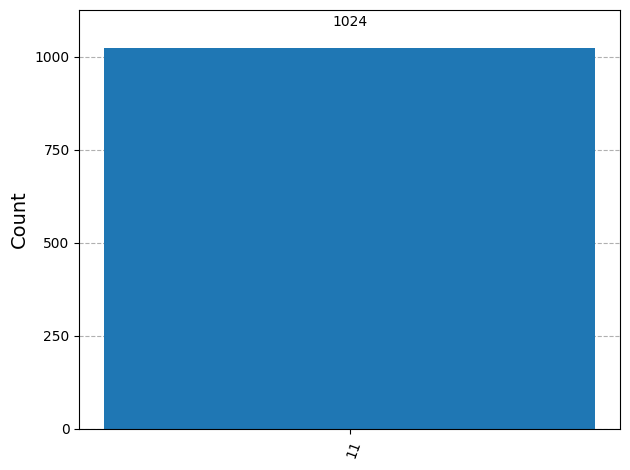

In [22]:
result = execute_on_simulater(circuit)